In [1]:
import os
import h5py
import numpy as np
from scipy.integrate import solve_ivp
from scipy.stats.qmc import Halton
from time import time
import matplotlib.pyplot as plt
from joblib import Parallel, delayed  # For parallel execution
import torch


import re

In [2]:
# File paths
old_file_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/Old equations/datasets/trials_many_alldata_v3.h5"
new_file_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton.h5"
exprimental_data_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional_2.txt"
exprimental_data_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional_2.h5"

In [3]:
import re
import numpy as np

def load_experimental_data(filepath):
    with open(filepath, 'r') as file:
        lines = file.readlines()

    data = []
    i = 0

    while i < len(lines):
        line = lines[i].strip()
        if re.match(r'^\d+_visit', line):  # Start of a new block
            metadata = {'id': line}
            i += 1

            # Read all key = value lines into metadata until reaching time series
            while i < len(lines):
                current_line = lines[i].strip()

                if not current_line:
                    i += 1
                    continue

                if ',' in current_line:  # start of time series
                    break

                match = re.match(r'(\w+)\s*=\s*([-\d.eE]+)', current_line)
                if match:
                    key, value = match.groups()
                    metadata[key] = float(value)

                i += 1

            # Time series data
            xy_data = []
            while i < len(lines) and not re.match(r'^\d+_visit', lines[i]):
                data_line = lines[i].strip()
                if ',' in data_line:
                    try:
                        x, y = map(float, data_line.split(','))
                        xy_data.append((x, y))
                    except ValueError:
                        pass
                i += 1

            data.append({
                'metadata': metadata,
                'xy': np.array(xy_data)
            })
        else:
            i += 1

    return data


# Usage
experimental_data = load_experimental_data(exprimental_data_path)

# Example: access first experiment's metadata and data
print(experimental_data[0]['metadata'])
# print(experimental_data[0]['metadata_2'])
print(experimental_data[0]['xy'][:5])  # First 5 data points


{'id': '01_visit1_t10_box1', 'f0': 0.0015893301480921773, 'ts': 17.200000000000003, 'h0': 4.587583245378116, 'J': 0.0, 'b1': 0.06280246128216688, 'b2': 0.0023367925487859822, 'Pc': 0.2449760450956942, 'φ': 0.4270356744367926, 'residual': 0.02351204593627817}
[[  1.4        123.3513031 ]
 [  1.6        122.17604065]
 [  1.8        122.04483795]
 [  2.         120.78048706]
 [  2.2        119.58672333]]


In [4]:
def save_experimental_data_to_hdf5(data, output_path):
    # Define variable-length float dtype
    vlen_float64 = h5py.special_dtype(vlen=np.float64)
    str_dtype = h5py.string_dtype(encoding='utf-8')

    # Prepare containers
    t_list, I_list, p_list = [], [], []

    for entry in data:
        xy = entry['xy']
        t_list.append(xy[:, 0])
        I_list.append(xy[:, 1])
        meta = entry['metadata']
        p_list.append((
            meta['id'],
            meta.get('J', np.nan),
            meta.get('b1', np.nan),
            meta.get('b2', np.nan),
            meta.get('f0', np.nan),
            meta.get('h0', np.nan),
            meta.get('ts', np.nan),
            meta.get('residual', np.nan)
        ))

    # Convert parameter list to structured array
    p_dtype = np.dtype([
        ('id', str_dtype),
        ('J', 'f8'),
        ('b1', 'f8'),
        ('b2', 'f8'),
        ('f0', 'f8'),
        ('h0', 'f8'),
        ('ts', 'f8'),
        ('residual', 'f8')
    ])
    p_array = np.array(p_list, dtype=p_dtype)

    # Write to HDF5
    with h5py.File(output_path, 'w') as h5f:
        h5f.create_dataset('t', data=np.array(t_list, dtype=object), dtype=vlen_float64)
        h5f.create_dataset('I', data=np.array(I_list, dtype=object), dtype=vlen_float64)
        h5f.create_dataset('p', data=p_array)

# Usage
save_experimental_data_to_hdf5(experimental_data, exprimental_data_path_h5)


In [5]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t = h5f['t'][:]       # time stamps for first experiment
    I = h5f['I'][:]       # intensity values for first experiment
    p = h5f['p']      # parameter tuple for first experiment
    t_group = h5f['t']
    h0_array = h5f['p']['h0']
    ts_array = h5f['p']['ts']
    id_array = h5f['p']['id']
    b1_primes = p['b1']              # in s^-1
    b2_primes = p['b2']              # in s^-1
    je_primes = p['J'] * 1e-6 / 60    # converting to m/s
    f0_primes = p['f0']              # in Hz
    experimental_residual = p['residual']
    

In [6]:
rho = 1e0 # Water density (Kg/L)  [Why Kg/L and not g/L or Kg/m^3?]
P_c_hat = 12.1e-6 # (m/s)
Vw = 18e-6 # Molar volume of water (m^3/Mol)
c_0 = 300 # Serum Osmolarity (Mol/m^3)
sigma_0 = 0.045 # N/m
mu = 1.3e-3 # Pa.s
f_cr = 0.002 # Critical fluorescence (%)

# Solute parameters
Mw_FL = 376e-3 # molecular weight of Na_2FL, (Kg/mol)

# Naperian extinction coefficient
eps_f = 1.75e7 # m^-1 M^-1
# transmittance parameter
fcr2 = rho * f_cr / Mw_FL


In [7]:
h_0_values = h0_array * 1e-6      # converting to m

b_1_values = b1_primes * ts_array

b_2_values = b2_primes * ts_array

J_e_values = je_primes * ts_array / h_0_values

f_0_values = f0_primes / f_cr

In [8]:
def scale_time_arrays(t):
    """
    Linearly scale each time array so that:
      - the first value becomes 0
      - the value equal to ts becomes 1

    Parameters:
    - t: list or array of 1D numpy arrays (ragged)
    - ts_array: 1D array of float, ts for each instance

    Returns:
    - t_scaled: list of scaled time arrays with same structure
    """
    t_scaled = []

    for i in range(len(t)):
        t_i = t[i]
        t0 = t_i[0]
        t_end = t_i[-1]  # Assuming ts is the last value in the array

        t_scaled_i = (t_i - t0) / (t_end - t0)
        t_scaled.append(t_scaled_i)

    return np.array(t_scaled, dtype=object)


In [9]:
t_scaled = scale_time_arrays(t)

# Example: t_scaled[0] should start at 0 and end at 1 (approximately)
print(t_scaled[0][0], t_scaled[0][-1])


0.0 1.0


In [10]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    I = h5f['I'][:]

# Scale each row so that the first value is 1
I_scaled = np.array([row / row[0] for row in I], dtype=object)

# Example: print first 5 values of the first scaled row
print(I_scaled[0][0])

1.0


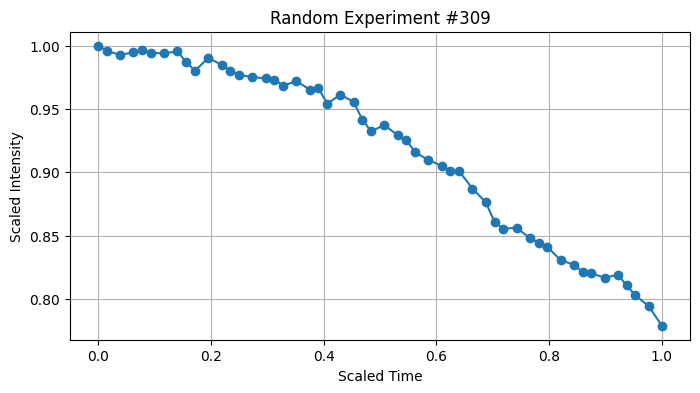

In [11]:
# Randomly select an index
idx = np.random.randint(len(I_scaled))

# Plot the selected row
plt.figure(figsize=(8, 4))
plt.plot(t_scaled[idx], I_scaled[idx], marker='o')
plt.xlabel('Scaled Time')
plt.ylabel('Scaled Intensity')
plt.title(f'Random Experiment #{idx}')
plt.grid(True)
plt.show()

In [12]:
from scipy.interpolate import PchipInterpolator

# Interpolate each row of t_scaled and I_scaled to length 601
n_points = 601
t_uniform = np.linspace(0, 1, n_points)

t_scaled_interp = []
I_scaled_interp = []

for t_row, I_row in zip(t_scaled, I_scaled):
    # Interpolators
    t_interp = t_uniform  # target x-axis
    I_interp_func = PchipInterpolator(t_row, I_row)
    I_interp = I_interp_func(t_interp)
    t_scaled_interp.append(t_interp)
    I_scaled_interp.append(I_interp)

t_scaled_interp = np.array(t_scaled_interp)
I_scaled_interp = np.array(I_scaled_interp)

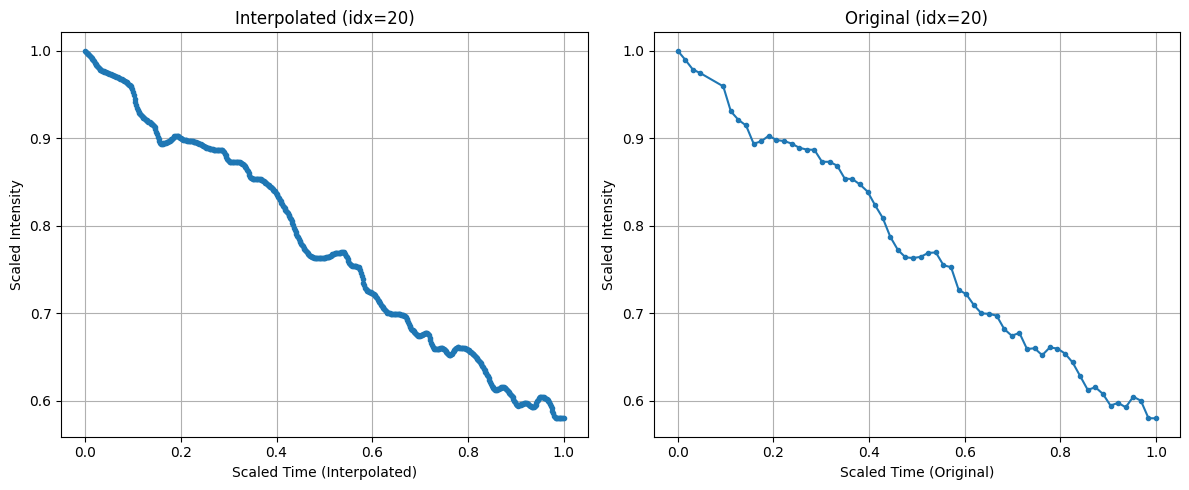

In [13]:
# Randomly select an index
idx = np.random.randint(len(I_scaled_interp))

plt.figure(figsize=(12, 5))

# Interpolated plot
plt.subplot(1, 2, 1)
plt.plot(t_scaled_interp[idx], I_scaled_interp[idx], marker='o', markersize=3, label='Interpolated')
plt.xlabel('Scaled Time (Interpolated)')
plt.ylabel('Scaled Intensity')
plt.title(f'Interpolated (idx={idx})')
plt.grid(True)

# Original plot
plt.subplot(1, 2, 2)
plt.plot(t_scaled[idx], I_scaled[idx], marker='o', markersize=3, label='Original')
plt.xlabel('Scaled Time (Original)')
plt.ylabel('Scaled Intensity')
plt.title(f'Original (idx={idx})')
plt.grid(True)

plt.tight_layout()
plt.show()

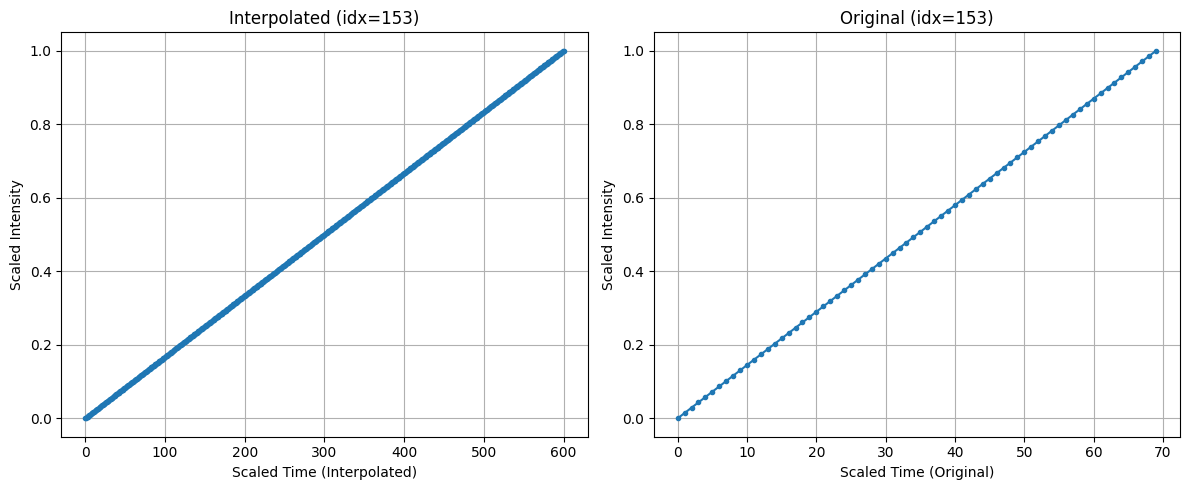

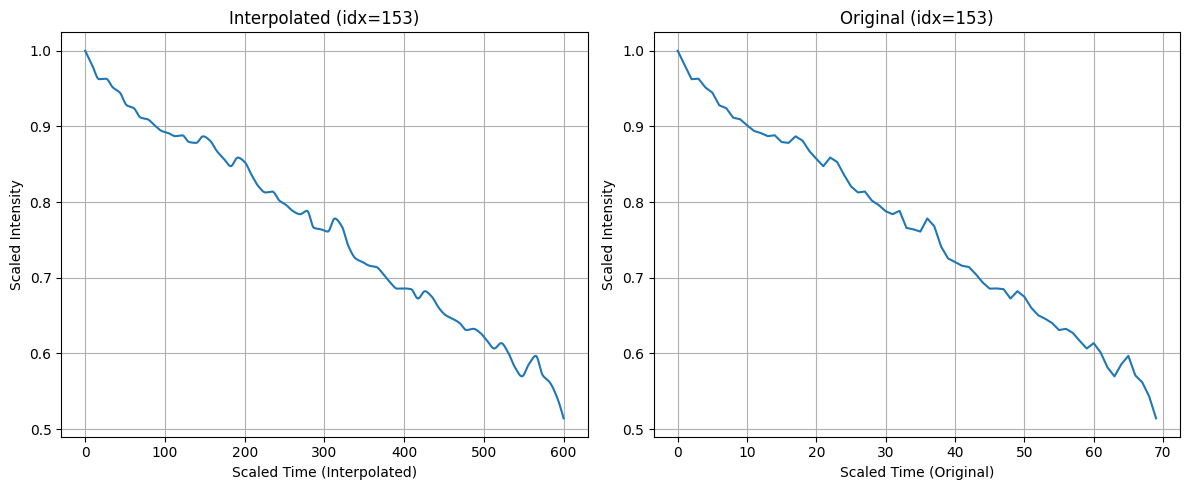

In [14]:
# Randomly select an index
idx = np.random.randint(len(I_scaled_interp))

plt.figure(figsize=(12, 5))

# Interpolated plot
plt.subplot(1, 2, 1)
plt.plot(t_scaled_interp[idx], marker='o', markersize=3, label='Interpolated')
plt.xlabel('Scaled Time (Interpolated)')
plt.ylabel('Scaled Intensity')
plt.title(f'Interpolated (idx={idx})')
plt.grid(True)

# Original plot
plt.subplot(1, 2, 2)
plt.plot(t_scaled[idx], marker='o', markersize=3, label='Original')
plt.xlabel('Scaled Time (Original)')
plt.ylabel('Scaled Intensity')
plt.title(f'Original (idx={idx})')
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

# Interpolated plot
plt.subplot(1, 2, 1)
plt.plot(I_scaled_interp[idx], label='Interpolated')
plt.xlabel('Scaled Time (Interpolated)')
plt.ylabel('Scaled Intensity')
plt.title(f'Interpolated (idx={idx})')
plt.grid(True)

# Original plot
plt.subplot(1, 2, 2)
plt.plot(I_scaled[idx], label='Original')
plt.xlabel('Scaled Time (Original)')
plt.ylabel('Scaled Intensity')
plt.title(f'Original (idx={idx})')
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
phi_values = eps_f*fcr2*h_0_values
Pc_values = P_c_hat*Vw*c_0/(h_0_values/ts_array)

In [16]:
exprimental_data_nondimensional_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_nondimensional_2.h5"

In [17]:
# Function to calculate I
def calculate_I(h, f, phi, I_0=1.0):
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)


In [18]:
# Differential system (P_c is a constant and does not need to be passed as an argument)
def differential_system(t, y, J_e, b_1, b_2, h_e, P_c):
    h, c = y
    g_t = b_1 * np.exp(-b_2 * t)
    dh_dt = -g_t * h - J_e * (1 - (h_e / h) ** 3) + P_c * (c - 1)
    dc_dt = -g_t * c - dh_dt * (c / h)
    return [dh_dt, dc_dt]

def generate_and_store_dataset():  
    valid_h, valid_c, valid_f, valid_I, valid_p, rejected_index = [], [], [], [], [], []
    time_grid = t_uniform  # Use the uniform grid already defined
    fixed_length = len(time_grid) 
    
    h_e = 0        # When we are assuming constant evaporation 
        
    def solve_single_instance(i):
        J_e, b_1, b_2, f_0, Pc, phi, h0, ts, residual = (J_e_values[i], b_1_values[i], b_2_values[i],
                                               f_0_values[i], Pc_values[i], phi_values[i], h_0_values[i], ts_array[i], experimental_residual[i])
        y0 = [1.0, 1.0]
        sol = solve_ivp(
            differential_system,
            [0., 1.],
            y0,
            t_eval=time_grid,
            args=(J_e, b_1, b_2, h_e, Pc),
            method='LSODA',
        )
        
        # if np.max(sol.y[0]) > 1.1 or np.min(sol.y[0]) < h_threshold / h0 or sol.y[0][-1] > 1.5 * np.min(sol.y[0]) or np.max(sol.y[1]) > 25:
        #     rejected_index.append(i)  # Store the index of rejected cases
        #     return None  # Skip rejected cases
        # elif sol.y[0].shape[0] < fixed_length:
        #     rejected_index.append(i)  # Store the index of rejected cases
        #     return None
        # else:
        h = sol.y[0]
        c = sol.y[1]
        f = f_0 * c
        I0 = 1 / calculate_I(h[0], f[0], phi, I_0=1.0)
        I = calculate_I(h, f, phi, I_0=I0)
        return h, c, f, I, (J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts, residual)

    results = Parallel(n_jobs=-1)(delayed(solve_single_instance)(i) for i in range(len(J_e_values)))
    filtered_results = [res for res in results if res is not None]
    
    # Unpacking results into numpy arrays for efficient storage
    valid_h, valid_c, valid_f, valid_I, valid_p = map(np.array, zip(*filtered_results))

    # Convert lists to NumPy arrays
    valid_h = np.array(valid_h)
    valid_c = np.array(valid_c)
    valid_f = np.array(valid_f)
    valid_I = np.array(valid_I)
    valid_p = np.array(valid_p)

    # Save data in HDF5 format
    with h5py.File(exprimental_data_nondimensional_path_h5, "w") as hdf_file:
        hdf_file.create_dataset("calculated_h", data=valid_h)
        hdf_file.create_dataset("calculated_c", data=valid_c)
        hdf_file.create_dataset("calculated_f", data=valid_f)
        hdf_file.create_dataset("calculated_I", data=valid_I)
        hdf_file.create_dataset("nondimensional_p", data=valid_p)
        
    print(f"Total accepted parameter sets: {valid_h.shape[0]}")
    return valid_h, valid_c, valid_f, valid_I, valid_p, rejected_index


start = time()
valid_h, valid_c, valid_f, valid_I, valid_p, rejected_index = generate_and_store_dataset()
end = time()
print(f"Time taken: {end - start:.2f} seconds")


Total accepted parameter sets: 467
Time taken: 2.19 seconds


In [19]:
datastore = h5py.File(exprimental_data_nondimensional_path_h5, 'r')
data_I = np.array(datastore["calculated_I"])
data_h = np.array(datastore["calculated_h"])
data_f = np.array(datastore["calculated_f"])

data_c = np.array(datastore["calculated_c"])
data_p = np.array(datastore["nondimensional_p"])

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
# device = "cpu"
print(f"Using {device} device")

Using cpu device


Parameters for n=451:
J_e: 0.0
b_1: 0.12930890087895303
b_2: 0.0
h_e: 0.0
f_0: 1.1990218049386292
P_c: 1.891732291492802
phi: 0.12458660722693496
ts: 38.75
h_0: 1.3384161233522157e-06
experimental residual: 0.0070257225572869725, calculated residual: 0.006753434260467852


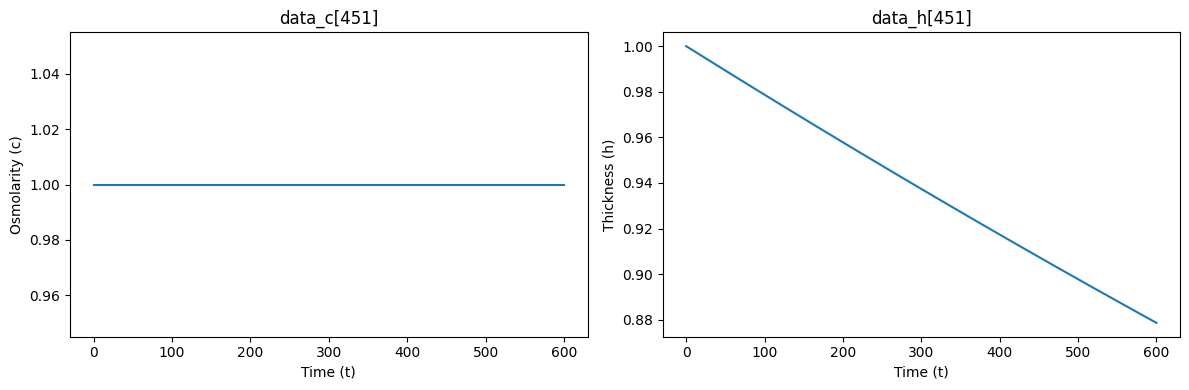

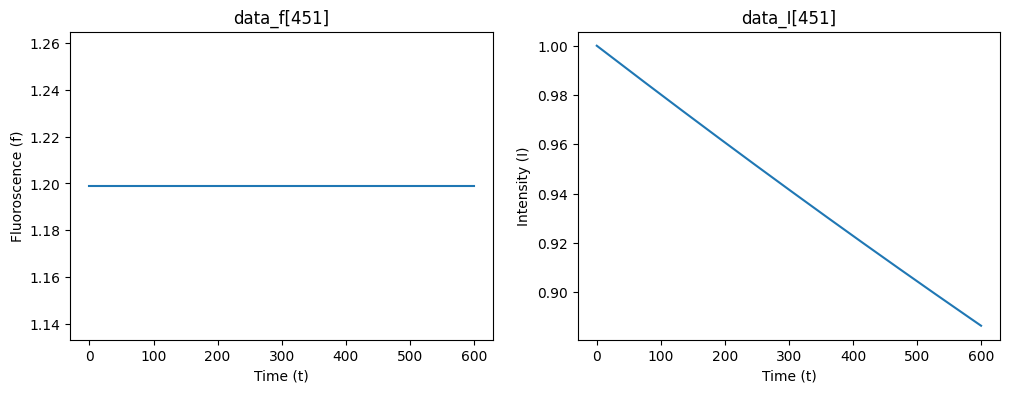

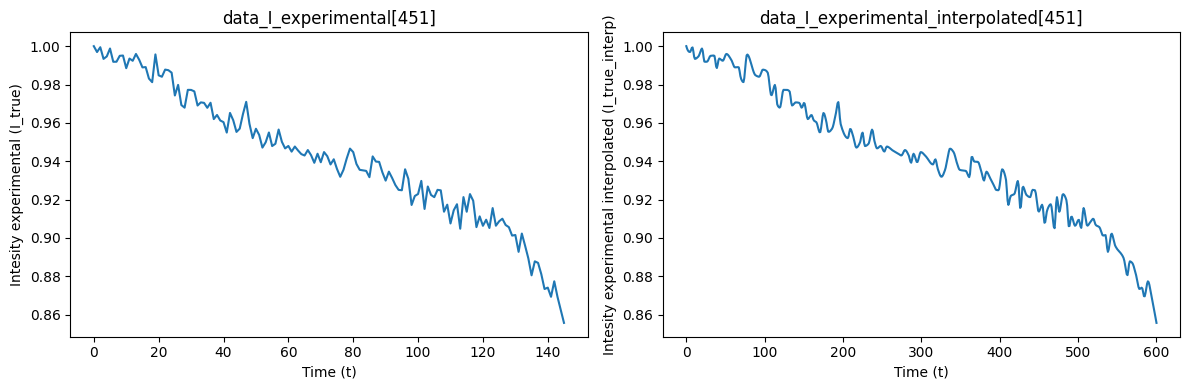

In [20]:
n = np.argmin(data_c[:,600])

print(f"Parameters for n={n}:")
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts, residual =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts: {ts}")
print(f"h_0: {h0}")
print(f"experimental residual: {residual}, calculated residual: {np.sqrt(np.mean((data_I[n] - I_scaled_interp[n])**2))}")

# Assuming n is the index and both data_c[n] and data_h[n] are 1D arrays
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_c[n])
axs[0].set_title('data_c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')

# Plot data_h[n]
axs[1].plot(data_h[n])
axs[1].set_title('data_h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_f[n])
axs[0].set_title('data_f[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Fluoroscence (f)')

# Plot data_h[n]
axs[1].plot(data_I[n])
axs[1].set_title('data_I[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Intensity (I)')

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 1 column

# Plot data_c[n]
axs[0].plot(I_scaled[n])
axs[0].set_title('data_I_experimental[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Intesity experimental (I_true)')


# Plot data_c[n]
axs[1].plot(I_scaled_interp[n])
axs[1].set_title('data_I_experimental_interpolated[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Intesity experimental interpolated (I_true_interp)')

plt.tight_layout()
plt.show()

Parameters for n=163:
J_e: 0.27896651904255176
b_1: 1.087753451529768
b_2: 0.0
h_e: 0.0
f_0: 0.44860925387270156
P_c: 0.08352721372609756
phi: 0.6990408702208333
ts_halton: 9.600000000000001
h_0: 7.509696205800953e-06
experimental residual: 0.013296659123196379, calculated residual: 0.013395787019386561


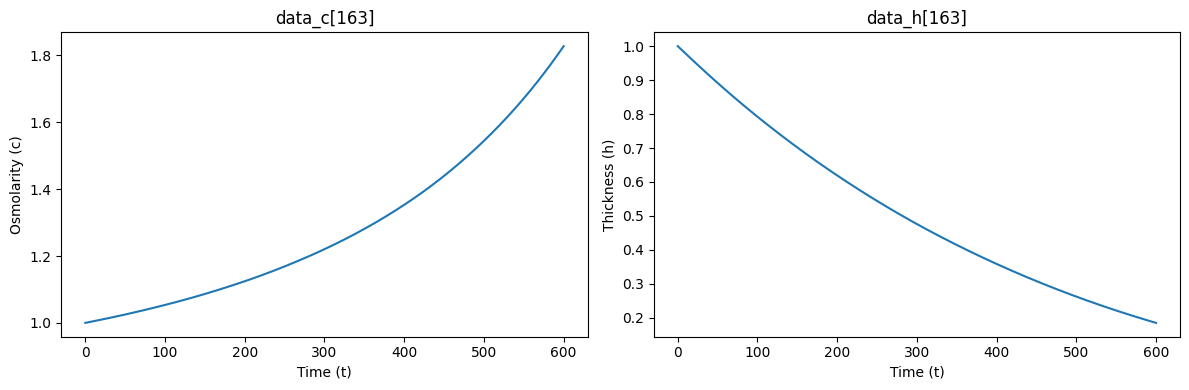

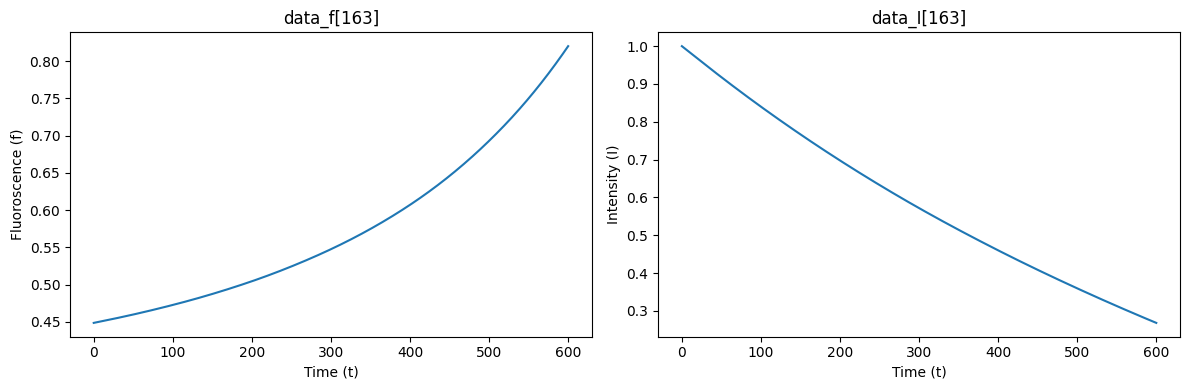

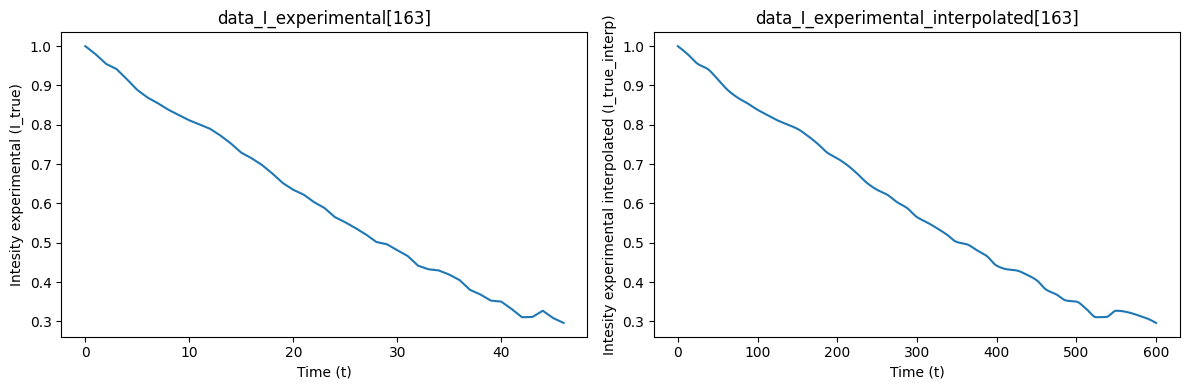

In [21]:
n = np.argmin(data_h[:,600])

print(f"Parameters for n={n}:")
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts, residual =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")
print(f"experimental residual: {residual}, calculated residual: {np.sqrt(np.mean((data_I[n] - I_scaled_interp[n])**2))}")

# Assuming n is the index and both data_c[n] and data_h[n] are 1D arrays
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_c[n])
axs[0].set_title('data_c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')

# Plot data_h[n]
axs[1].plot(data_h[n])
axs[1].set_title('data_h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_f[n])
axs[0].set_title('data_f[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Fluoroscence (f)')

# Plot data_h[n]
axs[1].plot(data_I[n])
axs[1].set_title('data_I[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Intensity (I)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 1 column

# Plot data_c[n]
axs[0].plot(I_scaled[n])
axs[0].set_title('data_I_experimental[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Intesity experimental (I_true)')


# Plot data_c[n]
axs[1].plot(I_scaled_interp[n])
axs[1].set_title('data_I_experimental_interpolated[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Intesity experimental interpolated (I_true_interp)')

plt.tight_layout()
plt.show()

Parameters for n=94:
J_e: 0.38787894652813926
b_1: -0.2724096981453484
b_2: 0.3365479161940786
h_e: 0.0
f_0: 1.3612588207402165
P_c: 0.6093282872878784
phi: 0.1776756822349644
ts_halton: 17.800000000000004
h_0: 1.9087444720099035e-06
experimental residual: 0.004189284253004378, calculated residual: 0.0038425091839894244


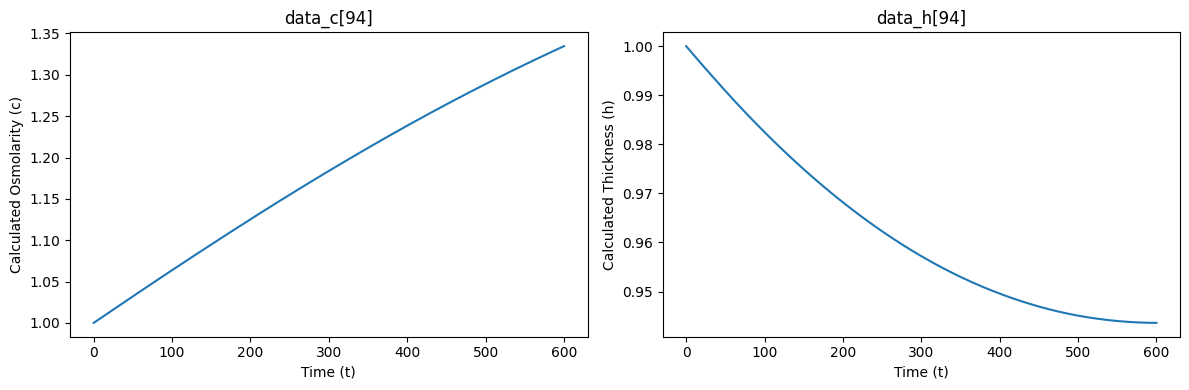

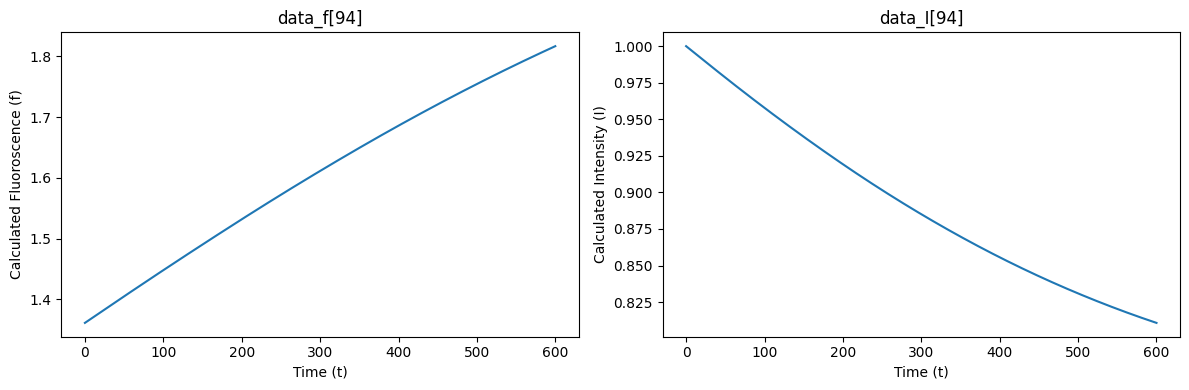

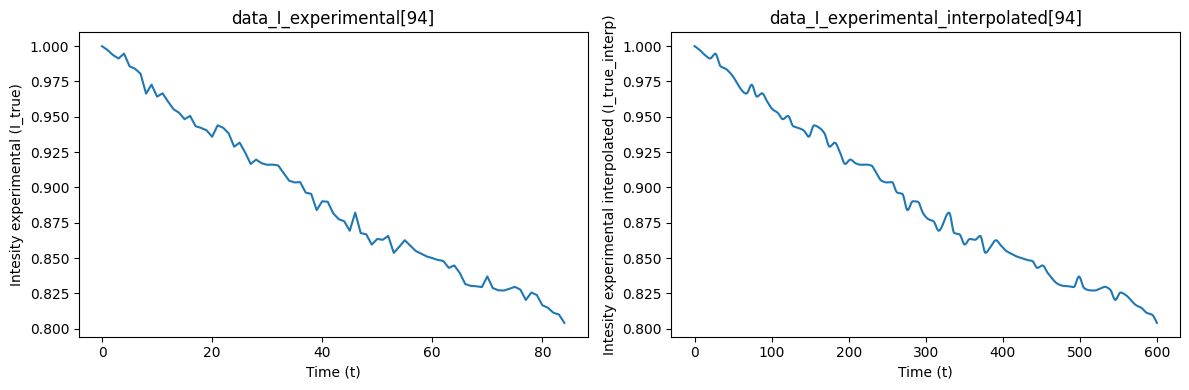

In [22]:
n = np.random.randint(len(data_c))

print(f"Parameters for n={n}:")
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts, residual =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")
print(f"experimental residual: {residual}, calculated residual: {np.sqrt(np.mean((data_I[n] - I_scaled_interp[n])**2))}")

# Assuming n is the index and both data_c[n] and data_h[n] are 1D arrays
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_c[n])
axs[0].set_title('data_c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Calculated Osmolarity (c)')

# Plot data_h[n]
axs[1].plot(data_h[n])
axs[1].set_title('data_h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Calculated Thickness (h)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_f[n])
axs[0].set_title('data_f[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Calculated Fluoroscence (f)')

# Plot data_h[n]
axs[1].plot(data_I[n])
axs[1].set_title('data_I[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Calculated Intensity (I)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 1 column

# Plot data_c[n]
axs[0].plot(I_scaled[n])
axs[0].set_title('data_I_experimental[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Intesity experimental (I_true)')


# Plot data_c[n]
axs[1].plot(I_scaled_interp[n])
axs[1].set_title('data_I_experimental_interpolated[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Intesity experimental interpolated (I_true_interp)')

plt.tight_layout()
plt.show()

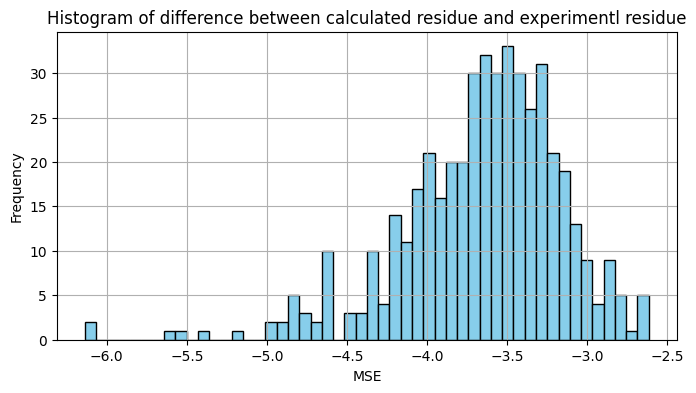

In [44]:
# Compute Relative MSE for each row
residue_difference = np.sqrt((np.sqrt(np.mean((data_I - I_scaled_interp) ** 2, axis=1))-data_p[:,-1])**2)

# Plot histogram
plt.figure(figsize=(8, 4))
plt.hist(np.log10(residue_difference), bins=50, color='skyblue', edgecolor='black')
plt.xlabel('MSE')
plt.ylabel('Frequency')
plt.title('Histogram of difference between calculated residue and experimentl residue')
plt.grid(True)
plt.show()

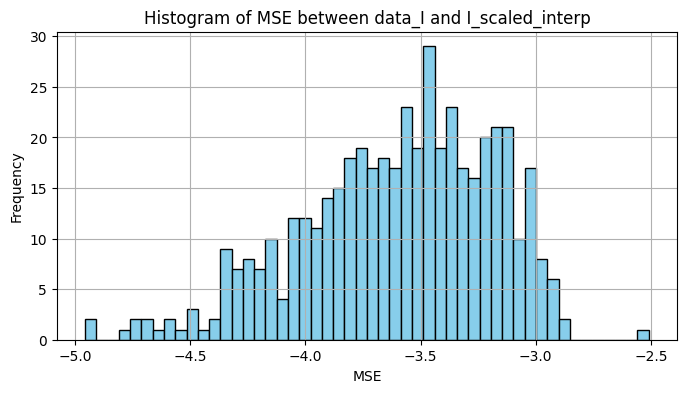

In [32]:
# Compute Relative MSE for each row
relative_mse_array = np.array([np.linalg.norm(data_I[i] - I_scaled_interp[i]) ** 2 / np.linalg.norm(I_scaled_interp[i])**2 for i in range(data_I.shape[0])])

# Plot histogram
plt.figure(figsize=(8, 4))
plt.hist(np.log10(relative_mse_array), bins=50, color='skyblue', edgecolor='black')
plt.xlabel('MSE')
plt.ylabel('Frequency')
plt.title('Histogram of MSE between data_I and I_scaled_interp')
plt.grid(True)
plt.show()

Parameters for n=101:
J_e: 0.14171542482720187
b_1: 0.3628486520857587
b_2: 11.5
h_e: 0.0
f_0: 1.2415081637106233
P_c: 0.1697265471206253
phi: 0.20605226752631634
ts_halton: 5.75
h_0: 2.2135900739969986e-06
experimental residual: 0.018728687253995176, calculated residual: 0.01654863893110136


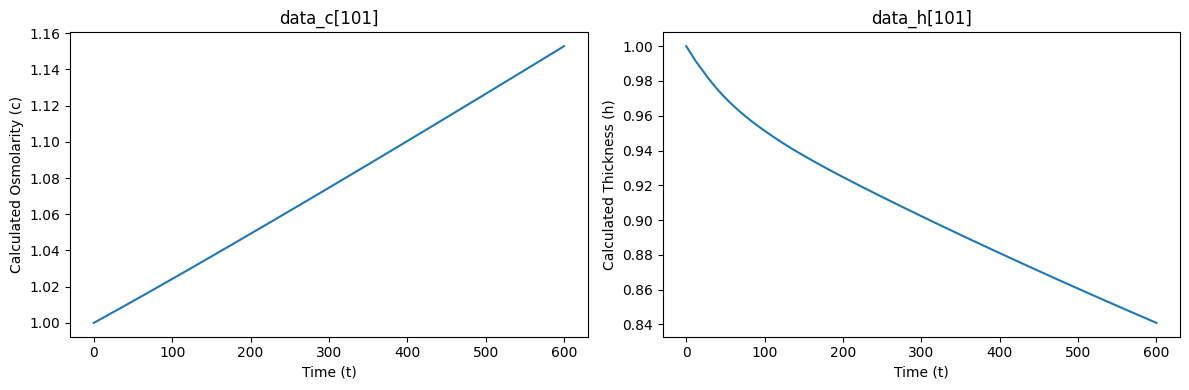

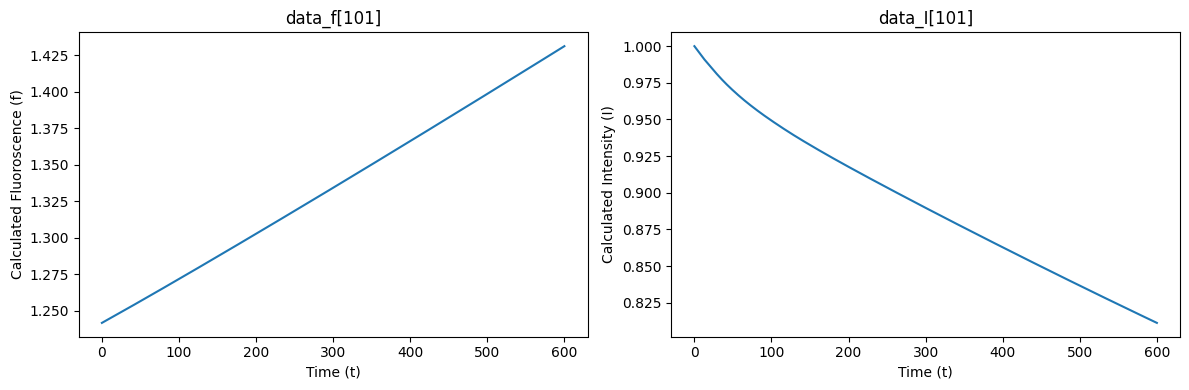

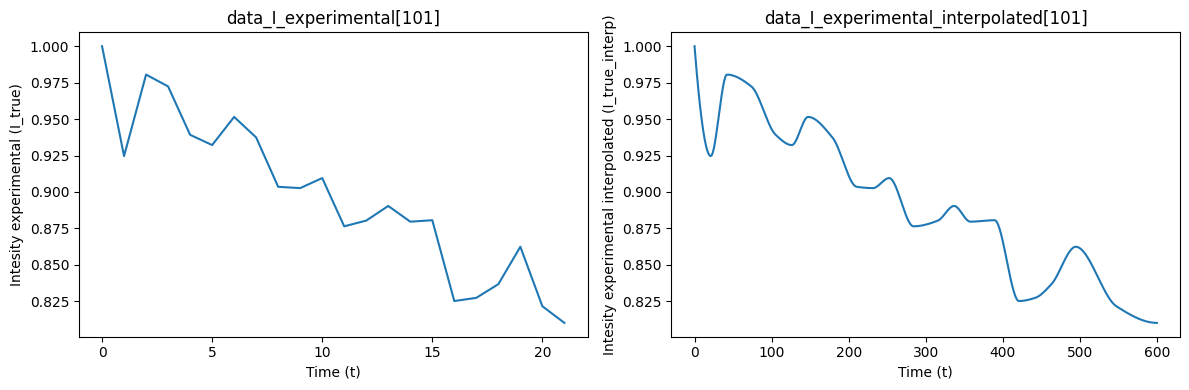

In [47]:
high_error_indices = np.where(np.log10(residue_difference) > -2.7)[0]

n = np.random.choice(high_error_indices)

print(f"Parameters for n={n}:")
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts, residual =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")
print(f"experimental residual: {residual}, calculated residual: {np.sqrt(np.mean((data_I[n] - I_scaled_interp[n])**2))}")

# Assuming n is the index and both data_c[n] and data_h[n] are 1D arrays
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_c[n])
axs[0].set_title('data_c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Calculated Osmolarity (c)')

# Plot data_h[n]
axs[1].plot(data_h[n])
axs[1].set_title('data_h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Calculated Thickness (h)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_f[n])
axs[0].set_title('data_f[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Calculated Fluoroscence (f)')

# Plot data_h[n]
axs[1].plot(data_I[n])
axs[1].set_title('data_I[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Calculated Intensity (I)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 1 column

# Plot data_c[n]
axs[0].plot(I_scaled[n])
axs[0].set_title('data_I_experimental[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Intesity experimental (I_true)')


# Plot data_c[n]
axs[1].plot(I_scaled_interp[n])
axs[1].set_title('data_I_experimental_interpolated[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Intesity experimental interpolated (I_true_interp)')

plt.tight_layout()
plt.show()